<a href="https://colab.research.google.com/github/rodolfocustodio/transfer-learning/blob/main/facial_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.1 MB/s eta 0:00:00


In [3]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from keras import layers
import tensorflow_datasets as tfds

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory

from ultralytics import YOLO

import glob
from IPython.display import Image, display


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
img_path = 'vistoria.png'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

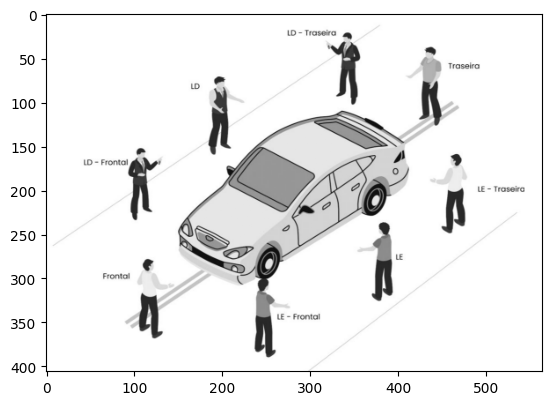

In [6]:
img = mpimg.imread(img_path)
imgplot = plt.imshow(img)
plt.show()

In [7]:
# Make a model with 2 layers
layer1 = keras.layers.Dense(3, activation="relu")
layer2 = keras.layers.Dense(3, activation="sigmoid")
model = keras.Sequential([keras.Input(shape=(3,)), layer1, layer2])

# Freeze the first layer
layer1.trainable = False

# Keep a copy of the weights of layer1 for later reference
initial_layer1_weights_values = layer1.get_weights()

# Train the model
model.compile(optimizer="adam", loss="mse")
model.fit(np.random.random((2, 3)), np.random.random((2, 3)))

# Check that the weights of layer1 have not changed during training
final_layer1_weights_values = layer1.get_weights()
np.testing.assert_allclose(
    initial_layer1_weights_values[0], final_layer1_weights_values[0]
)
np.testing.assert_allclose(
    initial_layer1_weights_values[1], final_layer1_weights_values[1]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step - loss: 0.1002


In [8]:
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(150, 150, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
base_model.trainable = False


In [10]:
inputs = keras.Input(shape=(150, 150, 3))
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning, as you will
# learn in a few paragraphs.
x = base_model(inputs, training=False)
# Convert features of shape `base_model.output_shape[1:]` to vectors
x = keras.layers.GlobalAveragePooling2D()(x)
# A Dense classifier with a single unit (binary classification)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)


In [11]:
import os
import shutil

# Configurações
data_dir = 'imagens' # Pasta contendo subpastas das classes
image_size = (150, 150)
batch_size = 32

# Fix for ValueError: No images found in directory imagens.
# image_dataset_from_directory expects subdirectories for classes.
# Create a default class subdirectory and move all images into it.
default_class_dir = os.path.join(data_dir, 'default_class')
if not os.path.exists(default_class_dir):
    os.makedirs(default_class_dir)

# Move all .jpg files from data_dir to default_class_dir
for filename in os.listdir(data_dir):
    if filename.endswith('.jpg') or filename.endswith('.jpeg') or filename.endswith('.png'):
        src_path = os.path.join(data_dir, filename)
        dest_path = os.path.join(default_class_dir, filename)
        if os.path.isfile(src_path): # Ensure it's a file, not a directory
            shutil.move(src_path, dest_path)

# 1. Carregar dataset de treinamento (80%)
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

# 2. Carregar dataset de validação (20%)
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

# 3. Pré-processamento: Normalização (pixels de 0-255 para 0-1)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 4. Otimizar para performance (carregamento rápido)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# O dataset está pronto para model.fit()


Found 410 files belonging to 1 classes.
Using 328 files for training.
Found 410 files belonging to 1 classes.
Using 82 files for validation.


In [12]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[keras.metrics.BinaryAccuracy()])
model.fit(train_ds, epochs=10, callbacks=[], validation_data=val_ds)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - binary_accuracy: 0.8343 - loss: 0.6538 - val_binary_accuracy: 1.0000 - val_loss: 0.0982
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - binary_accuracy: 1.0000 - loss: 0.0715 - val_binary_accuracy: 1.0000 - val_loss: 0.0219
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - binary_accuracy: 1.0000 - loss: 0.0195 - val_binary_accuracy: 1.0000 - val_loss: 0.0106
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - binary_accuracy: 1.0000 - loss: 0.0104 - val_binary_accuracy: 1.0000 - val_loss: 0.0073
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - binary_accuracy: 1.0000 - loss: 0.0076 - val_binary_accuracy: 1.0000 - val_loss: 0.0059
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - binary_accuracy: 1.0000 - loss: 0.0064 - val_binary_accuracy: 1.0000 - val_loss: 0.0051
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - binary_accuracy: 1.0000 - loss: 0.0051 - val_binary_accuracy: 1.0000 - val_loss: 0.0046
Epoch 8/10
11/11 ━━━

In [15]:
model_yolo = YOLO('yolov8n.pt')

In [16]:
source = 'img_teste.jpg' # or 'path/to/your/test_folder/' or 'your_video.mp4'

results = model_yolo.predict(source, save=True, imgsz=640, conf=0.5)


image 1/1 /content/img_teste.jpg: 640x480 3 persons, 483.4ms
Speed: 23.6ms preprocess, 483.4ms inference, 50.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


Results saved to: runs/detect/predict


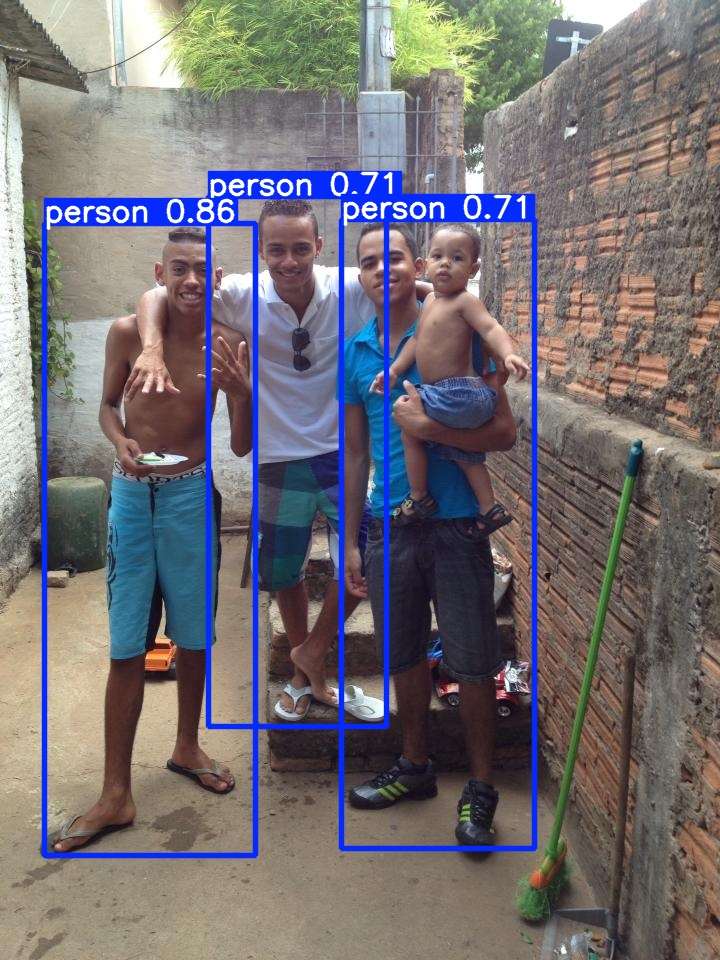

In [20]:
# Find the directory with the most recent results
latest_exp_dir = sorted(glob.glob('runs/detect/predict'))[-1]
print(f"Results saved to: {latest_exp_dir}")

# Display the resulting image (change the image name if you run on multiple images)
display(Image(filename=f'{latest_exp_dir}/img_teste.jpg', width=600))